In [4]:
import os

os.chdir('/home/jie/simulation/iarc_pred')
#os.chdir("/gpfhome/MLMS/MLMShhjs/scratch/CART-proteinLLM")

#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#print(os.environ.get("PYTORCH_CUDA_ALLOC_CONF"))

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import json
import pandas as pd
import numpy as np

file_path = "data/test_carc_ISSAN.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_test_issan = pd.DataFrame(data)

print(df_test_issan.head())
print(df_test_issan.columns)

                                              SMILES  \
0                           CCCCC(CC)COS(=O)(=O)[O-]   
1                                          ClCCOCCCl   
2                                            OCCNCCO   
3  CC(C)(C)CC(C)(C)c1ccc(OCCOCC[N+](C)(C)Cc2ccccc...   
4                               CC(C)(C)c1cc(O)ccc1O   

                                                   X  Carcinogen_class_test_y  
0  [0.3456071615219116, -0.39968448877334595, 0.1...                        0  
1  [0.25515902042388916, -0.36934196949005127, 0....                        0  
2  [0.3252815306186676, -0.4221317768096924, 0.03...                        0  
3  [0.3729228973388672, -0.5105491876602173, 0.09...                        0  
4  [0.4028189480304718, -0.5391305088996887, 0.11...                        0  
Index(['SMILES', 'X', 'Carcinogen_class_test_y'], dtype='object')


In [7]:
file_path = "data/Carcinogen_class_train.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_train = pd.DataFrame(data)

print(df_train.head())


X_train = np.array(df_train["X"].tolist())   # shape: (n_samples, n_features)
y_train = df_train["Carcinogen_class_y"].values

                                     SMILES  \
0                        CC(=O)Nc1ccc(O)cc1   
1  CC(=O)c1ccc(S(=O)(=O)NC(=O)NC2CCCCC2)cc1   
2   CC(C)=NNc1ncc(-c2ccc([N+](=O)[O-])o2)s1   
3                                  CC(C)=NO   
4              C=CC(OC(C)=O)c1ccc2c(c1)OCO2   

                                                   X  Carcinogen_class_y  
0  [0.3695492446422577, -0.5056324005126953, 0.12...                   1  
1  [0.39378437399864197, -0.4447822570800781, 0.0...                   0  
2  [0.3859923183917999, -0.6109945178031921, 0.05...                   1  
3  [0.29479867219924927, -0.46087270975112915, 0....                   1  
4  [0.4027533233165741, -0.47693103551864624, 0.0...                   1  


In [10]:
file_path = "data/test_carc_ISSAN.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_val = pd.DataFrame(data)


X_val = np.array(df_val["X"].tolist())   # shape: (n_samples, n_features)
y_val = df_val["Carcinogen_class_test_y"].values

In [9]:
df_val.columns

Index(['SMILES', 'X', 'Carcinogen_class_test_y'], dtype='object')

In [13]:
file_path = "data/test_carc_human.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_test = pd.DataFrame(data)


X_test = np.array(df_test["X"].tolist())   # shape: (n_samples, n_features)
y_test = df_test["Carcinogen_class_test_human_y"].values

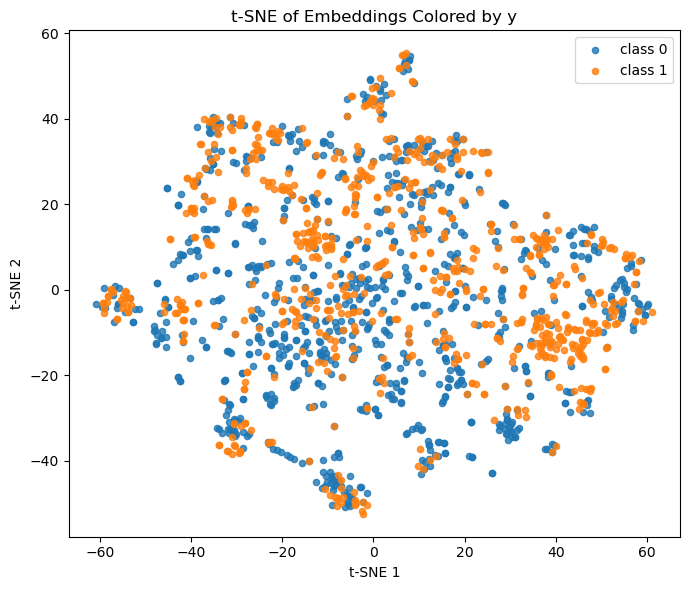

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# X: embedding matrix, shape (n_samples, n_features)


# Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(7, 6))

for cls in np.unique(y):
    idx = y == cls
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        s=20,
        alpha=0.8,
        label=f"class {cls}"
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Embeddings Colored by y")
plt.legend()
plt.tight_layout()
plt.show()





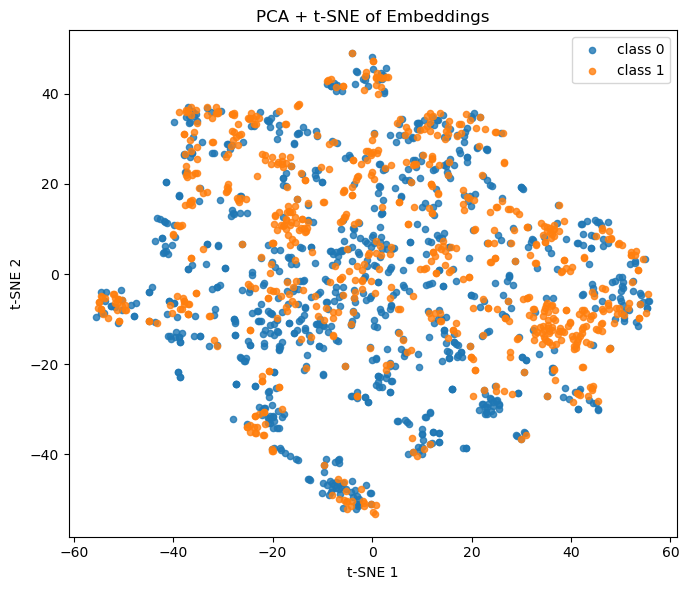

In [19]:
# PCA first
n_pca = min(50, X.shape[1], X.shape[0])
X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X)

# t-SNE
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
).fit_transform(X_pca)

# Plot
plt.figure(figsize=(7, 6))
for cls in np.unique(y):
    idx = y == cls
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=20, alpha=0.8, label=f"class {cls}")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("PCA + t-SNE of Embeddings")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# -----------------------
# Model
# -----------------------
class MLPClassifier(nn.Module):
    def __init__(self, in_dim=768, hidden=(200, 500, 768), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout and dropout > 0:
                layers += [nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]  # binary logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)  # (B,)


# -----------------------
# Preprocess (choose ONE)
# -----------------------
def preprocess_none(Xtr, Xva, Xte):
    return Xtr, Xva, Xte

def preprocess_l2norm(Xtr, Xva, Xte, eps=1e-12):
    def l2(x):
        n = np.linalg.norm(x, axis=1, keepdims=True)
        return x / (n + eps)
    return l2(Xtr), l2(Xva), l2(Xte)

def preprocess_standardize(Xtr, Xva, Xte, eps=1e-12):
    mu = Xtr.mean(axis=0, keepdims=True)
    sd = Xtr.std(axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (Xtr - mu) / sd, (Xva - mu) / sd, (Xte - mu) / sd


# -----------------------
# Metrics / Eval
# -----------------------
@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total = 0
    correct = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)  # (B,)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, yb.float())

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()

        total_loss += loss.item() * xb.size(0)
        correct += (preds == yb.long()).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total


# -----------------------
# Train
# -----------------------
def train_binary_mlp(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    hidden=(200, 500, 768),
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=64,
    epochs=300,
    patience=20,
    seed=42,
    # For imbalance: pos_weight = (#neg / #pos)
    pos_weight=None,
    # Preprocess: "none" | "l2" | "standardize"
    preprocess="none",
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    Xtr = np.asarray(X_train, dtype=np.float32)
    Xva = np.asarray(X_val, dtype=np.float32)
    Xte = np.asarray(X_test, dtype=np.float32)

    ytr = np.asarray(y_train, dtype=np.int64)
    yva = np.asarray(y_val, dtype=np.int64)
    yte = np.asarray(y_test, dtype=np.int64)

    assert Xtr.shape[1] == 768, f"Expected 768-d embeddings, got {Xtr.shape[1]}"
    assert set(np.unique(ytr)).issubset({0, 1}), "y_train must be 0/1 for binary classification"

    # ---- preprocessing ----
    if preprocess == "none":
        Xtr, Xva, Xte = preprocess_none(Xtr, Xva, Xte)
    elif preprocess == "l2":
        Xtr, Xva, Xte = preprocess_l2norm(Xtr, Xva, Xte)
    elif preprocess == "standardize":
        Xtr, Xva, Xte = preprocess_standardize(Xtr, Xva, Xte)
    else:
        raise ValueError("preprocess must be one of: 'none', 'l2', 'standardize'")

    # ---- loaders ----
    def make_loader(X, y, shuffle):
        Xt = torch.tensor(X, dtype=torch.float32)
        yt = torch.tensor(y, dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(Xtr, ytr, shuffle=True)
    val_loader   = make_loader(Xva, yva, shuffle=False)
    test_loader  = make_loader(Xte, yte, shuffle=False)

    # ---- model ----
    model = MLPClassifier(in_dim=768, hidden=hidden, dropout=dropout).to(device)

    # ---- loss (with optional pos_weight) ----
    if pos_weight is not None:
        pw = torch.tensor(float(pos_weight), dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)  # (B,)
            loss = criterion(logits, yb.float())
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running += loss.item() * xb.size(0)
            total += xb.size(0)

        train_loss = running / total
        val_loss, val_acc = evaluate(model, val_loader, device)

        # early stopping on val loss
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    val_loss, val_acc = evaluate(model, val_loader, device)
    test_loss, test_acc = evaluate(model, test_loader, device)
    print(f"Final | val_loss={val_loss:.4f} val_acc={val_acc:.4f} | test_loss={test_loss:.4f} test_acc={test_acc:.4f}")

    return model


# -----------------------
# Example usage
# -----------------------
# model = train_binary_mlp(
#     X_train, y_train, X_val, y_val, X_test, y_test,
#     hidden=(128, 64),
#     dropout=0.2,
#     preprocess="l2",
#     pos_weight=(num_neg / num_pos)  # if imbalanced
# )

In [ ]:


model = train_binary_mlp(
    X_train, y_train, X_val, y_val, X_test, y_test,
    hidden=(128, 64),
    dropout=0.2,
    preprocess="none",
    #pos_weight=(num_neg / num_pos)  # if imbalanced
)